#### JURNAL MODDUL 4
#### NURHIDAYAH MAULIDIA (F1D02410022)

#### IMPORT LIBRARY

In [102]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

#### FUNCTION RESIZE
Fungsi resize ini berfungsi untuk mengubah dimensi sebuah citra digital (skala abu-abu/grayscale) ke ukuran lebar (new_width) dan tinggi (new_height) yang baru secara manual menggunakan metode Nearest Neighbor Interpolation. Proses diawali dengan mengambil dimensi asli citra melalui properti image.shape, lalu membuat sebuah matriks kosong berwarna hitam (np.zeros) berukuran baru dengan tipe data piksel 8-bit (np.uint8). Melalui dua perulangan nested for, fungsi ini memetakan setiap koordinat piksel $(i, j)$ pada citra baru kembali ke koordinat $(y, x)$ pada citra asli berdasarkan rasio perbandingan ukuran lama dan baru. Dengan membulatkan hasil pembagian tersebut ke bilangan bulat terdekat menggunakan fungsi int(), nilai intensitas piksel dari citra asli langsung disalin ke citra baru, sehingga ukuran gambar berhasil diubah secara proporsional meskipun berisiko menghasilkan efek aliasing atau tangga pada tepian objek yang miring.

In [103]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

#### FUNCTION DILASI
Fungsi dilasi ini berfungsi untuk melakukan operasi morfologi dilasi (penebalan) secara manual pada sebuah citra biner (hitam-putih) menggunakan struktur elemen tertentu yang disebut kernel. Alur kerjanya dimulai dengan membuat matriks kosong (hasil) berukuran sama dengan citra asli, lalu memindai setiap piksel citra di luar area batas (border) menggunakan perulangan bertingkat. Ketika fungsi menemukan piksel objek berwarna putih (image[i, j] == 255), fungsi akan melakukan overlay (penimpaan) kernel di mana setiap koordinat tetangga yang bersesuaian dengan nilai kernel[k, l] == 1 akan dipaksa ikut menjadi putih (255) pada citra tujuan. Sebaliknya, jika piksel asli berwarna hitam dan belum diubah oleh proses dilasi piksel tetangganya, nilainya akan dipertahankan sebagai latar belakang hitam (0). Pengaruh akhir dari seluruh proses ini adalah memperluas, menebal, atau memperbesar ukuran objek putih di dalam citra, serta efektif untuk menutup lubang-lubang kecil (hole) atau menyambung garis kontur yang terputus.

In [104]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2

    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):

            if image[i, j] == 255:

                for k in range(k_height):
                    for l in range(k_width):

                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255

            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil

#### FUNCTION EROSI
Fungsi erosi ini berfungsi untuk melakukan operasi morfologi erosi (penipisan) secara manual pada citra biner menggunakan struktur elemen bernama kernel dengan prinsip kecocokan penuh (fit). Proses berjalan dengan memindai setiap piksel citra di luar batas menggunakan perulangan bertingkat, di mana setiap piksel bertindak sebagai titik acuan pusat kernel. Melalui variabel penanda cocok = True, fungsi akan memeriksa seluruh area tetangga yang superimposisi dengan nilai kernel[k, l] == 1; jika ditemukan setidaknya satu piksel pada citra asli yang bernilai hitam (0), maka kondisi kecocokan dianggap gagal (cocok = False) dan proses pengecekan langsung dihentikan (break). Piksel pada koordinat pusat tersebut hanya akan diubah menjadi putih (255) pada matriks hasil jika seluruh pola kernel terbukti cocok sempurna berada di dalam objek putih citra asli, sehingga pengaruh akhir dari operasi ini adalah mengikis pinggiran objek putih, memperkecil ukurannya, menghilangkan detail halus atau noise yang lebih kecil dari ukuran kernel, serta memisahkan objek yang saling berdekatan.

In [105]:
def erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape

    center_y = k_height // 2
    center_x = k_width // 2

    hasil = np.zeros((img_height, img_width), dtype=np.uint8)

    for i in range(center_y, img_height - center_y):
        for j in range(center_x, img_width - center_x):

            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1:
                        img_y = i + k - center_y
                        img_x = j + l - center_x

                        if image[img_y, img_x] == 0:
                            cocok = False
                            break
                if not cocok:
                    break

            if cocok:
                hasil[i, j] = 255

    return hasil

#### FUNCTION THINNING
Fungsi thinning ini merupakan implementasi manual dari Algoritma Zhang-Suen Skeletonization, sebuah metode iteratif yang berfungsi untuk menipiskan objek pada citra biner hingga menjadi kerangka penyusunnya (skeleton) dengan ketebalan hanya 1 piksel. Proses bekerja di dalam perulangan while yang terus berjalan mengecek tetangga 8-arah (P2 hingga P9) dari setiap piksel pusat (P1) dan mengumpulkan koordinat piksel yang memenuhi syarat eliminasi ke dalam daftar hapus. Algoritma ini membagi setiap iterasinya ke dalam dua sub-langkah (STEP 1 dan STEP 2) yang membedakan kondisi eliminasi pada arah mata angin kompas—yaitu kombinasi perkalian piksel utara-timur-selatan-barat—guna memastikan pengikisan lapisan luar objek putih terjadi secara simetris dari segala sisi tanpa memutus konektivitas struktur asli. Perulangan akan otomatis berhenti ketika nilai logika changed tetap bernilai False (artinya tidak ada lagi piksel yang memenuhi syarat untuk dikikis), lalu mengembalikan matriks citra biner akhir yang telah dikalikan 255 agar kerangka tangan atau objek tersebut kembali visual secara tegas dalam format skala hitam-putih standar.

In [106]:
def thinning(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

#### FUNCTION THRESHOLDING
Fungsi tersebut digunakan untuk melakukan proses thresholding (pengambangan) manual yang mengubah gambar biasa menjadi gambar biner (hitam-putih) berdasarkan nilai batas tertentu. Cara kerjanya adalah dengan membaca ukuran gambar, membuat matriks kosong baru, lalu memeriksa setiap piksel satu per satu menggunakan perulangan (looping); jika nilai kecerahan piksel pada gambar asli lebih besar atau sama dengan parameter angka maka piksel tersebut akan diubah menjadi putih bersih (255), sedangkan jika lebih kecil akan diubah menjadi hitam pekat (0), lalu hasilnya dikembalikan sebagai gambar baru.

In [107]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)

    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

#### FUNCTION THICKENING
Fungsi tersebut digunakan untuk melakukan proses penebalan objek (thickening) pada sebuah gambar biner (hitam-putih) dengan memanfaatkan operasi dilasi (dilation) yang diulang sebanyak parameter iterasi. Cara kerjanya dimulai dengan menduplikasi gambar asli ke variabel hasil agar data aslinya tidak rusak, lalu fungsi ini menjalankan perulangan (looping) sebanyak jumlah iterasi yang ditentukan untuk memanggil fungsi dilasi(hasil, kernel). Setiap kali fungsi dilasi dipanggil, piksel putih (objek) pada gambar akan diperluas atau dipertebal strukturnya berdasarkan bentuk elemen pemroses (kernel), sehingga setelah perulangan selesai, gambar yang objeknya sudah menebal akan dikembalikan sebagai hasil akhir.

In [108]:
def thickening(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = dilasi(hasil, kernel)
    return hasil

#### KERNEL UNTUK DETEKSI TEPI DAN PERBAIKAN CITRA
Kernel Sobel, Prewitt, dan Roberts adalah jenis filter diferensial yang digunakan untuk deteksi tepi (edge detection) pada gambar; varian dengan akhiran x berfungsi mendeteksi perubahan intensitas piksel secara horizontal (tepi vertikal), sedangkan akhiran y mendeteksi perubahan secara vertikal (tepi horizontal), dengan perbedaan utama terletak pada pembobotan nilai matriksnya (Sobel memberi bobot lebih besar di area tengah untuk mengurangi efek noise, Prewitt menggunakan bobot rata secara konstan, sementara Roberts menggunakan matriks silang berukuran kecil 2×2 yang sangat sensitif terhadap tepi diagonal). Di sisi lain, dua kernel terakhir digunakan untuk perbaikan citra (image enhancement), di mana kernelSmoothing berfungsi menghaluskan atau mengaburkan gambar (blurring) dengan cara meratakan nilai piksel tetangga agar noise berkurang, sedangkan kernelSharpening berfungsi memperjelas dan mempertegas detail atau kontras pada tepi gambar dengan cara menonjolkan perbedaan nilai piksel pusat terhadap sekelilingnya.

In [109]:
# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

#### FUNCTION KONVOLUSI
Fungsi tersebut digunakan untuk menerapkan operasi konvolusi 2D secara manual pada sebuah gambar (img) menggunakan matriks filter (kernel) untuk menghasilkan efek tertentu seperti deteksi tepi, penghalusan, atau penajaman. Cara kerjanya dimulai dengan menghitung ukuran padding setengah dari ukuran kernel (pad_size) dan menambahkannya di sekeliling gambar asli menggunakan nilai konstan (nol) agar piksel di bagian tepi gambar tetap bisa diproses dengan pas. Selanjutnya, fungsi membuat sebuah matriks kosong (canvas) berukuran sama dengan gambar asli sebagai wadah hasil, lalu melakukan perulangan (looping) bersandar untuk menggeser kernel ke setiap koordinat piksel; pada setiap posisi, fungsi akan mengambil area gambar yang sesuai ukuran kernel (region), mengalikannya elemen-demi-elemen dengan kernel, menjumlahkan total nilainya menggunakan np.sum, dan menyimpannya ke dalam canvas sebelum akhirnya mengembalikan gambar hasil konvolusi tersebut.

In [110]:
def konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size//2
    padded = np.pad(img, pad_size, mode = 'constant')
    
    canvas = np.zeros_like(img).astype(np.float32)
    h, w = img.shape
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            canvas [i, j] = np.sum(region * kernel)
            
    return canvas

#### FUNCTION DETEKSI TEPI
Fungsi tersebut digunakan untuk melakukan deteksi tepi (edge detection) secara menyeluruh pada sebuah gambar dengan cara menggabungkan hasil ekstraksi fitur struktur horizontal dan vertikal. Cara kerjanya dimulai dengan memanggil fungsi konvolusi dua kali menggunakan gambar asli terhadap kernelx dan kernely untuk menghasilkan matriks gradien arah horizontal (gx) dan vertikal (gy). Selanjutnya, kedua hasil gradien tersebut diubah menjadi nilai absolut menggunakan np.abs agar tidak ada nilai piksel negatif, lalu dijumlahkan ke dalam canvas untuk menyatukan semua komponen tepi dari kedua arah. Terakhir, fungsi memeriksa nilai tertinggi pada gambar hasil; jika tidak nol, nilai piksel akan dinormalisasi ke rentang kontras penuh $0$ hingga $255$, kemudian dibatasi nilainya menggunakan np.clip sebelum dikonversi ke tipe data gambar standar uint8 dan dikembalikan sebagai hasil akhir berupa gambar garis tepi yang tegas.

In [111]:
def edge(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = konvolusi(img, kernelx)
    gy = konvolusi(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

#### MENAMPILKAN CITRA ASLI, RESIZED, TEPI DAN THRESHOLD

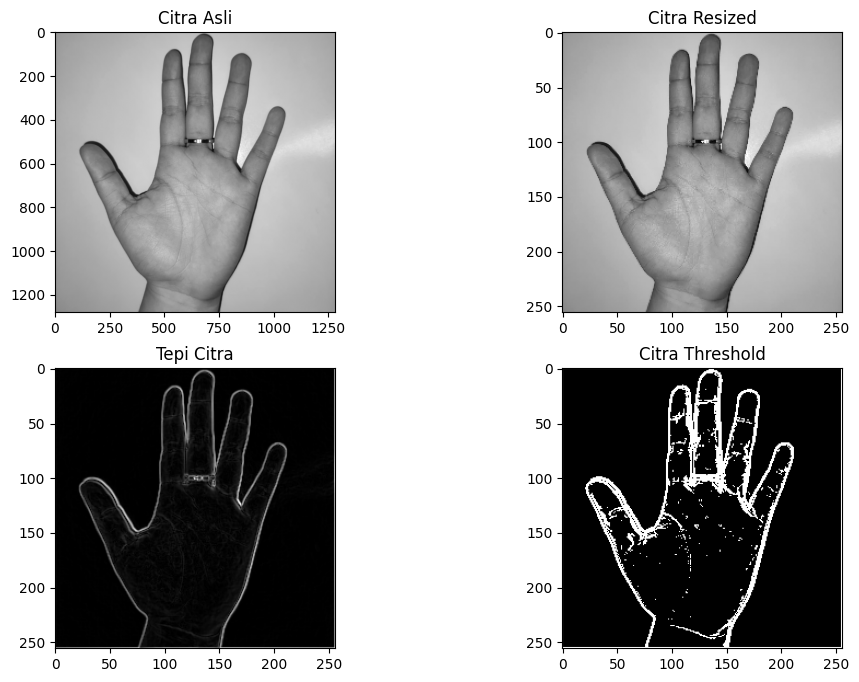

In [112]:
citraTanganAsli = cv.imread('assets/telapakTangan.jpeg', cv.IMREAD_GRAYSCALE)
citraTanganResized = resize(citraTanganAsli, 256, 256)

tepiTangan = edge(citraTanganResized, sobelx, sobely)
citraTanganThreshold = thresholding(tepiTangan, 20)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(citraTanganAsli, cmap='gray')
plt.title('Citra Asli')

plt.subplot(2,2,2)
plt.imshow(citraTanganResized, cmap='gray')
plt.title('Citra Resized')

plt.subplot(2,2,3)
plt.imshow(tepiTangan, cmap='gray')
plt.title('Tepi Citra')

plt.subplot(2,2,4)
plt.imshow(citraTanganThreshold, cmap='gray')
plt.title('Citra Threshold')

plt.show()


#### KERNEL UNTUK PROSES MORFOLOGI

In [113]:
kernel_diamond = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
])
kernel_cross = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])
kernel_x = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
], dtype=np.uint8)

#### MENAMPILKAN CITRA HASIL DILASI, EROSI, OPENING, CLOSING, THINNING, THICKENING DAN GRADIENT MORAPH (KERNEL 3X3)

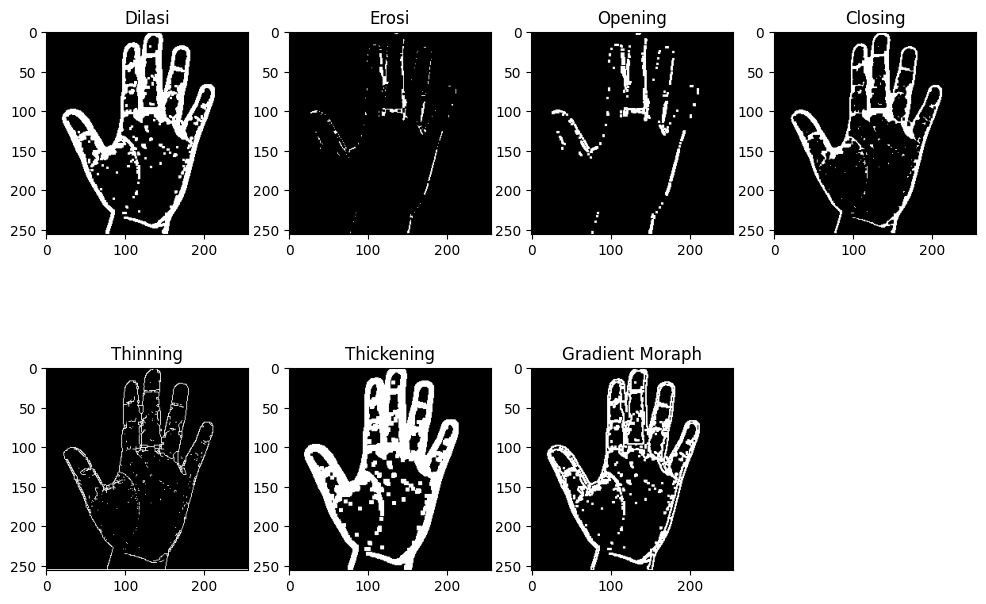

In [114]:
citraTanganDilatasi = dilasi(citraTanganThreshold, kernel_cross)
citraTanganErosi = erosi(citraTanganThreshold, kernel_cross)
citraTanganOpening = dilasi(erosi(citraTanganThreshold, kernel_cross), kernel_cross)
citraTanganClosing = erosi(dilasi(citraTanganThreshold, kernel_cross), kernel_cross)
citraTanganThinning = thinning(citraTanganThreshold)
citraTanganThickening = thickening(citraTanganThreshold, kernel_cross, iterasi = 2)
citraTanganGradientMoraph = np.clip(
    citraTanganDilatasi.astype(np.int32) - citraTanganErosi.astype(np.int32),
    0, 255
).astype(np.uint8)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.imshow(citraTanganDilatasi, cmap='gray')
plt.title('Dilasi')

plt.subplot(2,4,2)
plt.imshow(citraTanganErosi, cmap='gray')
plt.title('Erosi')

plt.subplot(2,4,3)
plt.imshow(citraTanganOpening, cmap='gray')
plt.title('Opening')

plt.subplot(2,4,4)
plt.imshow(citraTanganClosing, cmap='gray')
plt.title('Closing')

plt.subplot(2,4,5)
plt.imshow(citraTanganThinning, cmap='gray')
plt.title('Thinning')

plt.subplot(2,4,6)
plt.imshow(citraTanganThickening, cmap='gray')
plt.title('Thickening')

plt.subplot(2,4,7)
plt.imshow(citraTanganGradientMoraph, cmap='gray')
plt.title('Gradient Moraph')

plt.show()


#### ANALISIS PERBEDAAN CITRA SEBELUM MORFOLOGI DAN SETELAH MORFOLOGI

#### 1. Citra Threshold vs Citra Hasil Dilasi : Dibandingkan dengan citra threshold, hasil dilatasi menampilkan objek tangan jauh lebih tebal dan berisi. Dilasi menambahkan piksel putih di sekeliling elemen.

#### 2. Citra Threshold vs Citra Hasil Erosi : Hasil erosi menyebabkan penyusutan objek yang sangat besar. Tangan yang semula utuh pada citra threshold berubah menjadi garis tipis, dan sebagian besar strukturnya teputus-putus. Erosi mengikis piksel putih pada batas objek dan menghilangkan detail penting dari jari-jari tangan.

#### 3. Citra Threshold vs Citra Hasil Opening : Hasil Opening terlihat mirip dengan erosi, yaitu struktur objek terlihat terputus-putus jika dibandingkan dengan citra threshold.Karena opening adalah operasi erosi yang diikuti dengan dilasi, proses ini bertujuan menghaluskan kontur dan menghilangkan noise putih yang terisolasi. Namun, karena struktur jari pada citra threshold awal sudah cukup tipis, proses erosi di awal merusak struktur tersebut sebelum sempat dikembalikan oleh dilasi.

#### 4. Citra Threshold vs Citra Hasil Closing : Hasil closing memiliki kemiripan bentuk geometris yang paling tinggi dengan citra threshold, tetapi jauh lebih bersih, halus, dan solid. Closing bekerja dengan melakukan dilasi terlebih dahulu kemudian diikuti erosi.

#### 5. Citra Threshold vs Citra Hasil Thinning : Perbedaannya sangat kontras, jika citra threshold menampilkan volume dan bentuk utuh dari tangan, hasil thinning hanya menyisakan kerangka biner (skeleton). Thinning mengikis objek dari segala arah secara berulang. Seluruh garis tepi di reduksi menjadi garis-garis tunggal yang merepresentasikan arsitektur jari dan tangan.

#### 6. Citra Threshold vs Citra Hasil Thickening : Kebalikan dari hasil thinning, hasil thickening membuat objek tangan terlihat sangat gemuk, dan mendominasi ruang gambar dibandingkan citra threshold. Operasi ini memperluas luar objek biner secara signifikan. Area latar belakang hitam yang mengelilingi sela-sela jari pada citra threshold menjadi menyempit karena terdesak oleh penebalan piksel putih.

#### 7. Citra Threshold vs Citra Hasil Gradient Morphology : Citra threshold menampilkan objek tangan dalam bentuk blok putih padat, sedangkan Gradient Moraph hanya menampilkan garis tepi atau siluet luar-dalam yang kopong. Hasil diperoleh dari pengurangan antara citra hasil dilasi dengan citra erosi.


#### MENAMPILKAN CITRA HASIL DILASI, EROSI, OPENING, CLOSING, THINNING, THICKENING DAN GRADIENT MORAPH (KERNEL 5X5)

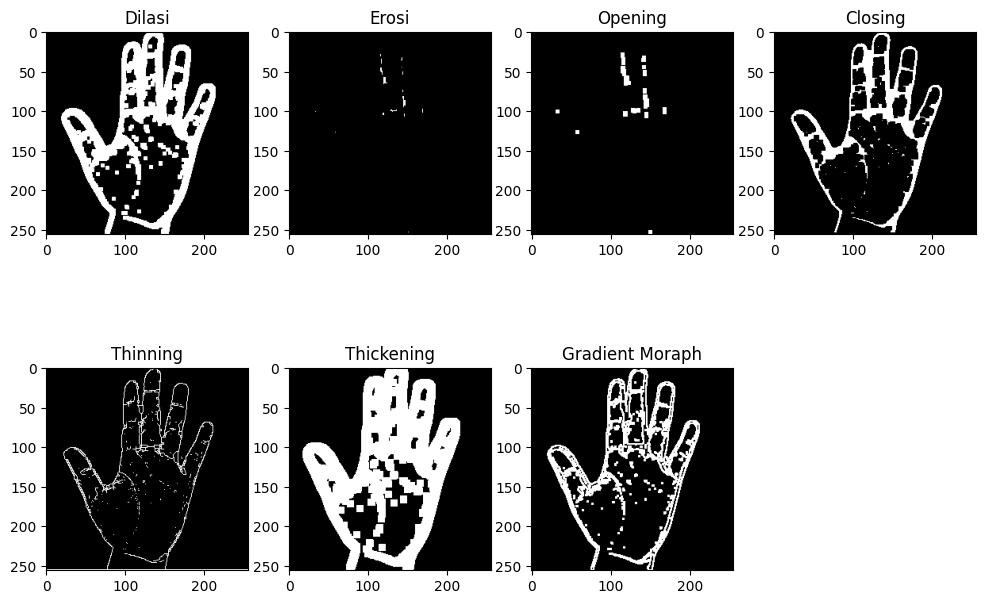

In [115]:
citraTanganDilatasi2 = dilasi(citraTanganThreshold, kernel_diamond)
citraTanganErosi2 = erosi(citraTanganThreshold, kernel_diamond)
citraTanganOpening2 = dilasi(erosi(citraTanganThreshold, kernel_diamond), kernel_diamond)
citraTanganClosing2 = erosi(dilasi(citraTanganThreshold, kernel_diamond), kernel_diamond)
citraTanganThinning2 = thinning(citraTanganThreshold)
citraTanganThickening2 = thickening(citraTanganThreshold, kernel_diamond, iterasi = 2)
citraTanganGradientMoraph2 = np.clip(
    citraTanganDilatasi.astype(np.int32) - citraTanganErosi.astype(np.int32),
    0, 255
).astype(np.uint8)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.imshow(citraTanganDilatasi2, cmap='gray')
plt.title('Dilasi')

plt.subplot(2,4,2)
plt.imshow(citraTanganErosi2, cmap='gray')
plt.title('Erosi')

plt.subplot(2,4,3)
plt.imshow(citraTanganOpening2, cmap='gray')
plt.title('Opening')

plt.subplot(2,4,4)
plt.imshow(citraTanganClosing2, cmap='gray')
plt.title('Closing')

plt.subplot(2,4,5)
plt.imshow(citraTanganThinning2, cmap='gray')
plt.title('Thinning')

plt.subplot(2,4,6)
plt.imshow(citraTanganThickening2, cmap='gray')
plt.title('Thickening')

plt.subplot(2,4,7)
plt.imshow(citraTanganGradientMoraph2, cmap='gray')
plt.title('Gradient Moraph')

plt.show()

#### ANALISIS PERBANDINGAN CITRA HASIL PROSES MORPHOLOGY KERNEL 5X5 DENGAN KERNEL 3X3

#### Dilatasi: Pada operasi dilatasi, kernel 5X5 memberikan penebalan objek putih yang sangat masif dan agresif ke arah latar belakang hitam, sehingga lubang-lubang hitam (noise) di dalam area telapak tangan jauh lebih cepat tertutup dan menyatu menjadi putih solid dibandingkan dengan kernel 3x3. Namun, efek samping dari kernel 5x5 ini membuat sela-sela jari menyempit drastis karena perluasan piksel putih yang terlalu dominan, sementara kernel 3x3 menghasilkan penebalan yang jauh lebih proporsional dan tetap menjaga pemisahan antar jari secara natural.

#### Erosi: Perbedaan yang sangat ekstrem terlihat pada operasi erosi, di mana penggunaan kernel 5x5 mengikis piksel putih secara masif hingga menghancurkan struktur utama tangan dan menyisakan sedikit titik putih samar di area jari tengah. Sebaliknya, kernel 3x3 melakukan pengikisan secara lebih konservatif dan halus, sehingga meskipun ukuran objek mengecil dan menipis, siluet geometris serta struktur utuh dari tangan dan kelima jari masih dapat dipertahankan dengan baik.

#### Opening: Pada proses opening (erosi lalu dilatasi), kernel 5x5 gagal mengembalikan bentuk asli objek karena tahap erosi di awal yang terlalu kuat telah melenyapkan sebagian besar piksel jari, sehingga hasil akhirnya hanya menyisakan potongan-potongan kotak biner yang terputus di area tengah. Sementara itu, kernel 3x3 berhasil menjalankan fungsi opening dengan baik, yaitu mengikis noise tepi yang runcing tanpa memotong struktur utama jari, sehingga menghasilkan bentuk tangan yang bersih namun tetap utuh.

#### Closing: Untuk operasi closing (dilatasi lalu erosi), kedua kernel sama-sama berhasil mempertahankan bentuk dasar tangan, tetapi kernel 5x5 jauh lebih efektif dalam membersihkan noise internal berupa lubang-lubang hitam di dalam telapak tangan hingga tampak hitam pekat di bagian tengahnya karena penggabungan piksel yang kuat. Di sisi lain, kernel 3x3 menghasilkan kontur tepi yang lebih halus dan detail, meskipun masih menyisakan sedikit bintik hitam kecil di dalam objek karena daya jangkau kernel yang lebih pendek.

#### Thinning: Pada operasi thinning, perbedaan terletak pada tingkat kebersihan cabang kerangka yang dihasilkan. Kernel 3x3 mereduksi volume objek secara presisi menjadi garis topologi tunggal setebal 1 piksel yang sangat detail mengikuti lekuk asli jari, sedangkan kernel 5x5 menghasilkan jalur kerangka yang lebih kaku dan cenderung memotong atau mengabaikan detail percabangan kecil pada ujung-ujung jari yang dianggap sebagai pencilan (outlier).

#### Thickening: Saat melakukan thickening, kernel 5x5 secara agresif mendesak area latar belakang hitam dan mengubah sela-sela jari menjadi blok biner putih yang kaku, bahkan menciptakan distorsi berbentuk persegi di bagian bawah pergelangan tangan. Sebaliknya, kernel 3x3 melakukan penebalan secara bertahap dan luwes, sehingga hasil pembengkakan objek biner tetap melengkung mengikuti anatomi luar dari bentuk tangan asli.

#### Gradient Morphology: Pada operasi gradient, kernel 5x5 menghasilkan garis kontur biner yang tebal, lebar, dan menyerupai pita putih yang membungkus siluet tangan akibat selisih jarak yang besar antara hasil dilatasi dan erosi. Sementara itu, kernel 3x3 menghasilkan garis tepi yang sangat tipis, tajam, dan presisi tinggi, yang secara akurat memetakan batas terluar objek biner tanpa memberikan kesan visual yang terlalu gemuk.


#### MENAMPILKAN CITRA HASIL KOMBINASI OPERATOR (OPENING + CLOSING), (CLOSING + OPENING), (OPENING + DILATASI), (CLOSING + EROSI) DENGAN MENGGUNAKAN KERNEL 3X3

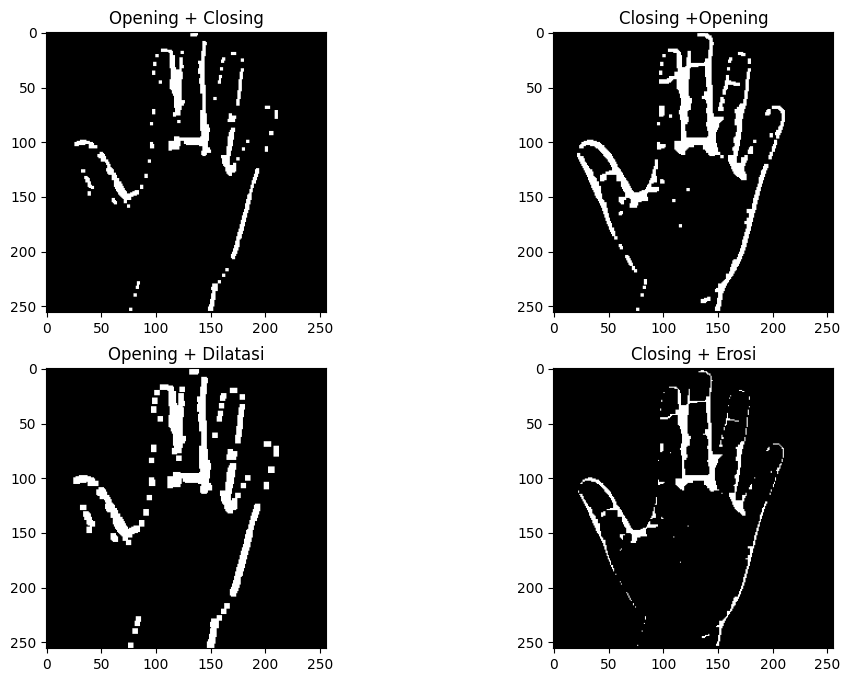

In [116]:
opening_closing = erosi(dilasi(citraTanganOpening, kernel_cross), kernel_cross)
closing_opening = dilasi(erosi(citraTanganClosing, kernel_cross), kernel_cross)
opening_dilasi = dilasi(citraTanganOpening, kernel_cross)
closing_erosi = erosi(citraTanganClosing, kernel_cross)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(opening_closing, cmap='gray')
plt.title('Opening + Closing')

plt.subplot(2,2,2)
plt.imshow(closing_opening, cmap='gray')
plt.title('Closing +Opening')

plt.subplot(2,2,3)
plt.imshow(opening_dilasi, cmap='gray') 
plt.title('Opening + Dilatasi')

plt.subplot(2,2,4)
plt.imshow(closing_erosi, cmap='gray')
plt.title('Closing + Erosi')

plt.show()


#### ANALISIS PERBEDAAN CITRA ASLI, MORFOLOGI DAN KOMBINASI

#### Proses pemrosesan citra diawali dengan mengubah citra asli menjadi Citra Threshold, yang menghasilkan representasi biner berupa kontur tangan. Namun, citra threshold ini masih dipenuhi oleh banyak noise internal berupa bintik-bintik putih di dalam telapak tangan serta tepi objek yang belum sempurna. Ketika operasi morfologi tunggal dikombinasikan, terjadi perubahan signifikan pada struktur objek. Operasi yang diawali dengan Opening (seperti Opening + Closing dan Opening + Dilatasi) terbukti sangat agresif dan efektif dalam menghapus komponen noise kecil di latar belakang dan telapak tangan, meskipun harus mengorbankan keutuhan bentuk dengan membuat kontur jari menjadi terfragmentasi atau putus-putus. Sebaliknya, kombinasi yang diawali dengan Closing (seperti Closing + Opening dan Closing + Erosi) jauh lebih unggul dalam menjaga keutuhan struktur bentuk objek. Pada Closing + Opening, kontur jari tangan berhasil tersambung secara optimal dan tampak lebih tebal karena celah-celah kosong diisi terlebih dahulu sebelum area dibersihkan. Sementara itu, kombinasi Opening + Dilatasi menghasilkan garis objek yang paling tebal dan kaku, sedangkan Closing + Erosi menghasilkan batas objek yang paling tipis, tajam, dan halus yang sangat ideal untuk pelacakan tepi yang presisi.

#### FILTERING

In [117]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    # ratakan array 
                    values = region.ravel()
                    # hitung kemunculan 
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

# cara panggil 
# hasil = filter_citra(foto_karim, 3, 'mean')

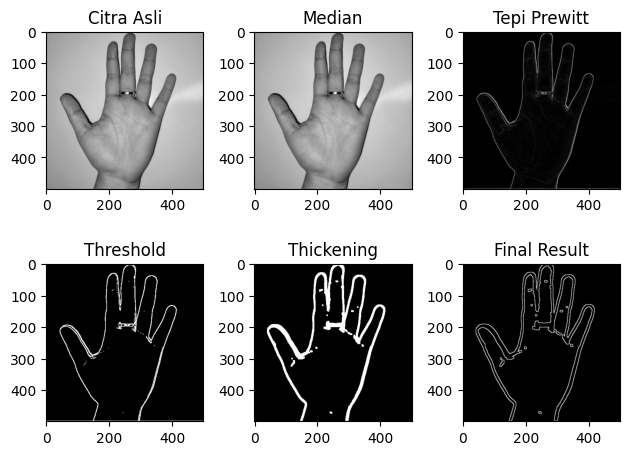

In [118]:
citraTangan = cv.imread('assets/telapakTangan.jpeg', cv.IMREAD_GRAYSCALE)
resized_tangan = resize(citraTangan, 500, 500)
median = filter_citra(resized_tangan, 3, 'median')
tepi_prewitt = edge(median, prewittx, prewitty)
threshold = thresholding(tepi_prewitt, 30)
thick = thickening(threshold, kernel_cross, iterasi=2)
tepi_prewitt1 = edge(thick, prewittx, prewitty)

plt.Figure(figsize=(10, 10))
plt.subplot(2,3,1)
plt.imshow(resized_tangan, cmap='gray')
plt.title('Citra Asli')

plt.subplot(2,3,2)
plt.imshow(median, cmap='gray')
plt.title('Median')

plt.subplot(2,3,3)
plt.imshow(tepi_prewitt, cmap='gray')
plt.title('Tepi Prewitt')

plt.subplot(2,3,4)
plt.imshow(threshold, cmap='gray')
plt.title('Threshold')

plt.subplot(2,3,5)
plt.imshow(thick, cmap='gray')
plt.title('Thickening') 

plt.subplot(2,3,6)  
plt.imshow(tepi_prewitt1, cmap='gray')
plt.title('Final Result')

plt.tight_layout()
plt.show()

#### ANALISIS PENGGUNAAN MASING-MASING PROSES
#### Proses ini digunakan untuk menghasilkan visualisasi kontur tangan yang bersih, utuh, dan tegas melalui beberapa tahapan terintegrasi. Diawali dengan resize untuk menyamakan skala citra dan mengoptimalkan beban komputasi, alur dilanjutkan dengan filter median yang berfungsi mereduksi bintik noise halus tanpa mengaburkan batas objek. Selanjutnya, operator Prewitt pertama mengekstrak gradien intensitas tepi yang kemudian dipertegas menjadi hitam-putih murni melalui proses thresholding guna membuang sisa gradasi abu-abu yang samar. Untuk mengatasi kendala garis kontur yang terputus akibat pencahayaan, proses morfologi thickening diterapkan sebanyak dua iterasi menggunakan kernel cross agar garis menjadi lebih tebal, solid, dan menyatu secara utuh. Sebagai sentuhan akhir, penerapan operator Prewitt kedua di atas garis tebal tersebut menghasilkan efek double-edge (dua garis tipis paralel), yang memberikan hasil akhir berupa visualisasi outline tangan yang sangat tajam, presisi, dan bebas dari kesan buram (blurry).